# Visualização de Dados com Pandas
### Análise Exploratória Completa: Dataset de Vendas de Videogame

---

> **Profª. Suzana Mota: Curso Técnico - Inteligência Artificial - IFNMG (Ceadi)**
>
> Aluno: Antonio Ray Martins Vieira



---
# Análise Exploratória Completa

Agora que aprendemos todos os comandos, vamos aplicá-los em conjunto
para responder perguntas reais sobre os dados de vendas de videogame.

**Fluxo da análise:**
1. Configuração de Ambiente e Carregar dados
2. Identificar e tratar problemas de qualidade
3. Explorar os dados limpos
4. Responder perguntas de negócio

In [ ]:
# Importe a biblioteca pandas
import pandas as pd

In [ ]:
# ATENÇÃO: Carregando o dataset COM PROBLEMAS DE QUALIDADE
# Este arquivo foi criado propositalmente com dados sujos para fins de aprendizado
# Insira este link
#'https://raw.githubusercontent.com/suzanasvm/visualizacao_de_dados/refs/heads/main/datasets/vendas_videogame_dados_sujos.csv'
url = 'https://raw.githubusercontent.com/suzanasvm/visualizacao_de_dados/refs/heads/main/datasets/vendas_videogame_dados_sujos.csv'

# Faca a leitura dos dados
df = pd.read_csv(url)

#Mostre as 10 primeiras linhas
df.head(10)

,ID_Cliente,Categoria,Nome_Item,Quantidade_Vendida,Preco_Unitario,Preco_Final,Data_Venda,Mes_Ano,Ano
0,1129,Luta,Mortal Kombat,4.0,270.0,1080.0,2026-12-17,12-2026,2026
1,1476,Mario,Mario Kart,5.0,220.0,1100.0,2026-03-07,03-2026,2026
2,1106,Mario,Super Mario Bros,NaN,200.0,NaN,2025-11-12,11-2025,2025
3,1358,Luta,Street Fighter,NaN,250.0,NaN,2026-04-24,04-2026,2026
4,1143,Mario,Mario Kart,NaN,220.0,NaN,2024-01-10,01-2024,2024
5,1246,RPG,Pokemon,NaN,230.0,NaN,2026-03-10,03-2026,2026
6,1191,Mario,Mario Kart,1.0,220.0,NaN,2025-08-16,08-2025,2025
7,1156,Mario,Super Mario Bros,2.0,200.0,400.0,2024-11-25,11-2024,2024
8,1422,Luta,Street Fighter,1.0,250.0,250.0,2026-09-08,09-2026,2026
9,1481,Aventura,GTA,5.0,280.0,1400.0,2026-12-01,12-2026,2026


### Etapa 1: Visão geral inicial

In [ ]:
print('VISÃO GERAL DO DATASET')
# Quantidade linhas e colunas do dataset
print('Linhas e colunas:', df.shape)

# Quais sao as colunas do dataset
print('Colunas:', df.columns.tolist())

VISÃO GERAL DO DATASET
Linhas e colunas: (100, 9)
Colunas: ['ID_Cliente', 'Categoria', 'Nome_Item', 'Quantidade_Vendida', 'Preco_Unitario', 'Preco_Final', 'Data_Venda', 'Mes_Ano', 'Ano']


In [ ]:
# Resumo estatístico das colunas numéricas
df.describe()

,ID_Cliente,Quantidade_Vendida,Preco_Unitario,Preco_Final,Ano
count,100.000000,87.000000,92.000000,95.000000,100.00000
mean,1260.970000,3.505747,249.239130,872.947368,2025.49000
std,146.221325,1.803572,31.665619,438.066044,0.73161
min,1005.000000,1.000000,200.000000,220.000000,2024.00000
25%,1133.000000,2.000000,227.500000,470.000000,2025.00000
50%,1276.000000,4.000000,250.000000,900.000000,2026.00000
75%,1386.000000,5.000000,280.000000,1200.000000,2026.00000
max,1497.000000,6.000000,300.000000,1800.000000,2026.00000


### Etapa 2: Diagnóstico de qualidade dos dados

In [ ]:
# Diagnóstico completo de valores ausentes
print('DIAGNÓSTICO DE QUALIDADE')

# Mostre os valores ausentes por coluna
print('\nValores ausentes por coluna:')
print(df.isnull().sum())

# Mostre a quantidade de linhas duplicadas
print('\nQuantidade de linhas duplicadas:', df.duplicated().sum())

DIAGNÓSTICO DE QUALIDADE

Valores ausentes por coluna:
ID_Cliente             0
Categoria              0
Nome_Item              0
Quantidade_Vendida    13
Preco_Unitario         8
Preco_Final            5
Data_Venda             0
Mes_Ano                0
Ano                    0
dtype: int64

Quantidade de linhas duplicadas: 0


### Etapa 3: Limpeza dos dados

Com base no diagnóstico, tomamos decisões sobre cada coluna com problemas.

In [ ]:
# Criamos uma cópia limpa para trabalhar
df_limpo = df.copy()

# 1. Remover linhas completamente duplicadas
df_limpo = df_limpo.drop_duplicates()

# 2. Preencher Quantidade_Vendida com 1 (1 unidade)
df_limpo['Quantidade_Vendida'] = df_limpo['Quantidade_Vendida'].fillna(1)

# 3. Preencher Preco_Unitario (Preenchido com a mediana)
df_limpo['Preco_Unitario'] = df_limpo['Preco_Unitario'].fillna(df_limpo['Preco_Unitario'].median())

# 4. Para Preco_Final, removemos as linhas nulas (é dado essencial para análise financeira)
df_limpo = df_limpo.dropna(subset=['Preco_Final'])

# Quantidade de linhas e colunas após limpeza
print('Linhas e colunas após limpeza:', df_limpo.shape)

Linhas e colunas após limpeza: (95, 9)


In [ ]:
# Diagnóstico do dataset após limpeza
print('Valores ausentes após limpeza:')
print(df_limpo.isnull().sum())

Valores ausentes após limpeza:
ID_Cliente            0
Categoria             0
Nome_Item             0
Quantidade_Vendida    0
Preco_Unitario        0
Preco_Final           0
Data_Venda            0
Mes_Ano               0
Ano                   0
dtype: int64


### Etapa 4: Perguntas de negócio

Agora com os dados limpos, respondemos perguntas reais sobre as vendas.

In [ ]:
# Pergunta 1: Quais categorias de jogos existem no dataset?
print('Categorias de jogos:')
print(df_limpo['Categoria'].unique())

Categorias de jogos:
['Luta' 'Mario' 'Aventura' 'Esporte' 'RPG' 'Sandbox' 'Corrida']


In [ ]:
# Pergunta 2: Quantas vendas existem por categoria?
print('Vendas por categoria:')
print(df_limpo['Categoria'].value_counts())

Vendas por categoria:
Categoria
Aventura    26
Luta        17
Mario       14
RPG         14
Sandbox     10
Esporte      7
Corrida      7
Name: count, dtype: int64


In [ ]:
# Pergunta 3: Qual é o faturamento total?
faturamento_total = df_limpo['Preco_Final'].sum()
print(f'Faturamento total: R$ {faturamento_total:,.2f}')

Faturamento total: R$ 82,930.00


In [ ]:
# Pergunta 4: Quais são as vendas de alto valor (acima de R$ 1.000)?
vendas_alto_valor = df_limpo[df_limpo['Preco_Final'] > 1000]
print('Vendas acima de R$ 1.000:')
print(vendas_alto_valor[['Nome_Item', 'Categoria', 'Preco_Final']])

Vendas acima de R$ 1.000:
           Nome_Item Categoria  Preco_Final
0      Mortal Kombat      Luta       1080.0
1         Mario Kart     Mario       1100.0
9                GTA  Aventura       1400.0
12               GTA  Aventura       1120.0
16    Street Fighter      Luta       1500.0
18           Pokemon       RPG       1380.0
19               GTA  Aventura       1680.0
23  Super Mario Bros     Mario       1200.0
24           Pokemon       RPG       1150.0
26  Super Mario Bros     Mario       1200.0
29             Zelda  Aventura       1500.0
30              FIFA   Esporte       1040.0
32              FIFA   Esporte       1040.0
34           Pokemon       RPG       1380.0
35             Zelda  Aventura       1500.0
40    Need for Speed   Corrida       1260.0
45               GTA  Aventura       1120.0
49              FIFA   Esporte       1560.0
50           Pokemon       RPG       1150.0
51    Need for Speed   Corrida       1260.0
52             Zelda  Aventura       1800.0
53    

In [ ]:
# Pergunta 5: Quais vendas são da categoria Mario com preço acima de R$ 500?
mario_caro = df_limpo[(df_limpo['Categoria'] == 'Mario') & (df_limpo['Preco_Final'] > 500)]
print('Vendas Mario acima de R$ 500:')
print(mario_caro[['Nome_Item', 'Preco_Final']])

Vendas Mario acima de R$ 500:
           Nome_Item  Preco_Final
1         Mario Kart       1100.0
15        Mario Kart        880.0
23  Super Mario Bros       1200.0
26  Super Mario Bros       1200.0
44  Super Mario Bros        800.0
64  Super Mario Bros       1200.0
65  Super Mario Bros       1200.0
76        Mario Kart       1320.0
84  Super Mario Bros        600.0
92        Mario Kart       1100.0


In [ ]:
# Pergunta 6: Qual é o ticket médio (preço médio por venda) por categoria?
ticket_medio = df_limpo.groupby('Categoria')['Preco_Final'].mean().sort_values(ascending=False)
print('Ticket médio por categoria:')
print(ticket_medio.round(2))

Ticket médio por categoria:
Categoria
Aventura    985.38
Esporte     965.71
Corrida     930.00
Mario       861.43
Luta        835.88
RPG         772.14
Sandbox     696.00
Name: Preco_Final, dtype: float64


In [ ]:
# Pergunta 7: Quais foram as vendas de 2026?
vendas_2026 = df_limpo[df_limpo['Ano'] == 2026]
print('Quantidade de vendas em 2026:', len(vendas_2026))
print(vendas_2026[['Nome_Item', 'Categoria', 'Preco_Final']])

Quantidade de vendas em 2026: 61
         Nome_Item Categoria  Preco_Final
0    Mortal Kombat      Luta       1080.0
1       Mario Kart     Mario       1100.0
8   Street Fighter      Luta        250.0
9              GTA  Aventura       1400.0
10            FIFA   Esporte        780.0
..             ...       ...          ...
91             GTA  Aventura       1400.0
93           Zelda  Aventura       1200.0
94           Zelda  Aventura       1200.0
98         Pokemon       RPG       1150.0
99         Pokemon       RPG        230.0

[61 rows x 3 columns]


In [ ]:
# Pergunta 8: Qual jogo gerou mais faturamento?
faturamento_por_jogo = df_limpo.groupby('Nome_Item')['Preco_Final'].sum().sort_values(ascending=False)
print('Faturamento por jogo:')
print(faturamento_por_jogo)

Faturamento por jogo:
Nome_Item
Zelda               14700.0
GTA                 10920.0
Pokemon             10810.0
Street Fighter       8000.0
Super Mario Bros     7000.0
Minecraft            6960.0
FIFA                 6760.0
Need for Speed       6510.0
Mortal Kombat        6210.0
Mario Kart           5060.0
Name: Preco_Final, dtype: float64


In [ ]:
# Pergunta 9: Quais vendas tiveram quantidade acima da média?
media_quantidade = df_limpo['Quantidade_Vendida'].mean()
acima_media = df_limpo[df_limpo['Quantidade_Vendida'] > media_quantidade]
print(f'Média de quantidade: {media_quantidade:.2f}')
print(f'Vendas acima da média: {len(acima_media)}')

Média de quantidade: 3.29
Vendas acima da média: 44


<Axes: title={'center': 'Participação de Cada Categoria no Faturamento Total (%)'}>

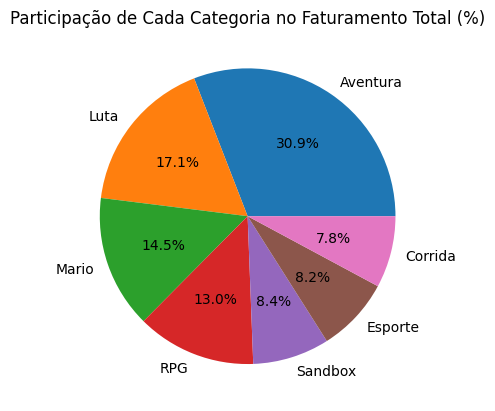

In [ ]:
# Pergunta de negócio
# Qual categoria de jogo mais contribui para o faturamento total da loja?
faturamento_categoria = df_limpo.groupby('Categoria')['Preco_Final'].sum().sort_values(ascending=False)
faturamento_categoria.plot(kind='pie', title='Participação de Cada Categoria no Faturamento Total (%)', autopct='%1.1f%%', ylabel='')

<Axes: title={'center': 'Faturamento Acumulado ao Longo do Tempo'}, xlabel='Mes_Ano'>

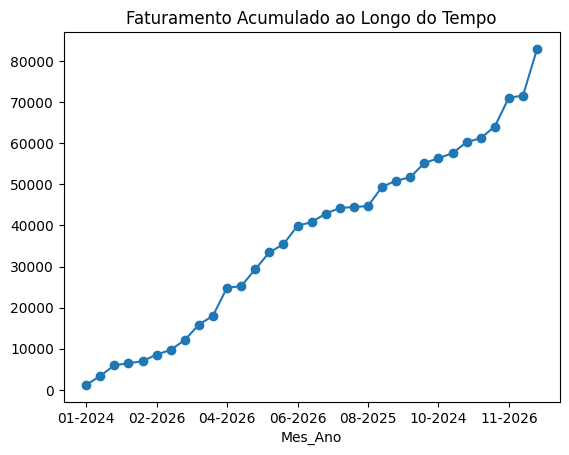

In [ ]:
# Pergunta de negócio
# O faturamento cresceu ou caiu ao longo do tempo?
faturamento_tempo = df_limpo.groupby('Mes_Ano')['Preco_Final'].sum().cumsum()
faturamento_tempo.plot(kind='line', title='Faturamento Acumulado ao Longo do Tempo', marker='o')